# LINEAR REGRESSION MODEL

Description of Boston Dataset in Sklearn

The Boston Housing dataset contains several columns that are used to describe various aspects of residential homes in Boston. Here is a description of each column in the dataset:

CRIM: Per capita crime rate by town. It indicates the level of crime in the area.

ZN: Proportion of residential land zoned for lots over 25,000 sq.ft. This feature reflects the area's residential density.

INDUS: Proportion of non-retail business acres per town. This is an indicator of the commercial use of land away from residential areas.

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise). This indicates whether the property is near the Charles River, which may add to the aesthetic value of the neighborhood.

NOX: Nitric oxides concentration (parts per 10 million). It represents the level of industrial pollutants in the area.

RM: Average number of rooms per dwelling. More rooms typically indicate more spacious accommodation.

AGE: Proportion of owner-occupied units built prior to 1940. Older structures might lack newer amenities or could be considered more prestigious depending on the architecture and condition.

DIS: Weighted distances to five Boston employment centres. This feature measures the accessibility to workplaces, which can influence housing prices.

RAD: Index of accessibility to radial highways. Higher values indicate easier access to major roadways.

TAX: Full-value property-tax rate per $10,000. This reflects the annual property tax rate.

PTRATIO: Pupil-teacher ratio by town. Lower values typically indicate better educational facilities, which is a significant factor for families when choosing a home.

A. Import Libraries

In [1]:
# Import Libraries
import numpy as np                                      # For numerical data processing, manipulation, etc.
import pandas as pd                                     # For numerical data processing, manipulation, etc.
import matplotlib.pyplot as plt                         # For data visualization
from numpy.conftest import dtype
from sklearn.linear_model import LinearRegression       # For Linear Regression model
from sklearn.metrics import mean_squared_error          # For Linear regression model evaluation
from sklearn.impute import SimpleImputer                # For the implementation of Simple Imputer to deal with missing values
from sklearn.model_selection import train_test_split    # For splitting dataset as training values and test values
import seaborn as sns
from sklearn.preprocessing import StandardScaler

B. Load Dataset

In [2]:
df = pd.read_csv("boston.csv")                      # Load the dataset from the csv file. Store data in pandas dataframe df
df.head(10)                                         # Show the first 10 dataframe

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,6,NaN,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


C. Data Cleaning

In [3]:
# Data cleaning: Find missing values
missing_values = df.isnull().sum()
missing_values

Unnamed: 0    0
crim          6
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64

In [4]:
# If one of the columns is having a missing data, implement simple imputation.

# This tuple will store all the keys from the dataframe that has missing values
col_Has_Val_Missed = []

# Iterate over the dataframe to check for any missing values
for col_name, series in missing_values.items():
    if series != 0:
        col_Has_Val_Missed.append(col_name)
        print(col_Has_Val_Missed)
    else:
        pass

# Missing value flag: "No missing values -> False / Missing Values -> True"
is_Val_Missed = False if len(col_Has_Val_Missed) == 0 else True

# If there is missing value, apply imputation via mean strategy
if  is_Val_Missed:
    imputer = SimpleImputer(strategy='median')
    for col_name in col_Has_Val_Missed:
        imputer.fit(df[[col_name]])
        df[col_name] = imputer.transform(df[[col_name]])

df.head(10)

#recheck_missing_values = df.isnull().sum()
#recheck_missing_values


['crim']


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,6,0.26042,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [5]:
round(df.describe(), 2)

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,253.50,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,146.21,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,1.00,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,127.25,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,253.50,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,379.75,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,506.00,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [6]:
process_data = df
process_data.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

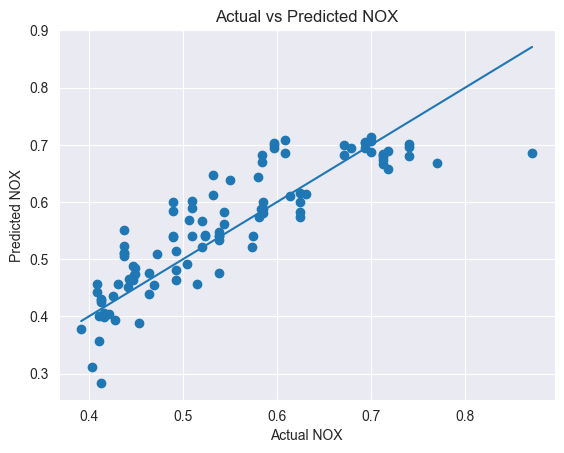

0.003057349099965879

In [18]:
#x_reg = process_data.drop(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'], axis = 1)
#x_reg = process_data.drop(['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'lstat', 'medv'], axis = 1)
#y_reg = process_data['nox']
#scaler = StandardScaler()
#scaled_x_reg = scaler.fit_transform(x_reg)
#scaled_x_reg
#x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(scaled_x_reg, y_reg, test_size = 0.2, random_state = 42)

x_reg = process_data.drop(['indus', 'nox'], axis = 1)
y_reg = process_data['nox']

scaler = StandardScaler()
scaled_x_reg = scaler.fit_transform(x_reg)

x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(scaled_x_reg, y_reg, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(x_reg_train, y_reg_train)

y_pred = model.predict(x_reg_test)

plt.figure()
plt.scatter(y_reg_test, y_pred)
plt.xlabel("Actual NOX")
plt.ylabel("Predicted NOX")
plt.title("Actual vs Predicted NOX")
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()])
plt.show()


mse = mean_squared_error(y_reg_test, y_pred)
mse


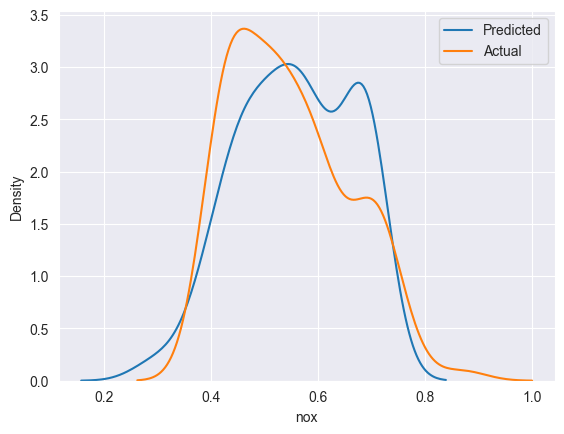

In [19]:
sns.kdeplot(y_pred, label = 'Predicted')
sns.kdeplot(y_reg_test, label = 'Actual')
plt.legend()
plt.show()